# How are in-demand skills trending for Data Analysts?

#### Methology
1. Aggregate skill counts yearly
2. Re-analyze based on percentage of total jobs
3. Plot the yearly skill demand

## Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  

df = pd.read_csv("../Data/job_postings_flat.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Group the Skills by Year

In [17]:
## Skill count per month for data analysts
df_DA_US = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US['job_posted_year'] = df_DA_US['job_posted_date'].dt.year

# Explode job_skills column
df_DA_US_explode = df_DA_US.explode('job_skills')
df_DA_US_explode.sample(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_year
47335,Data Analyst,Data Analyst,"Chicago, IL",via BeBee,Full-time,False,"Illinois, United States",2023-01-16 19:18:25,False,False,United States,NaN,NaN,NaN,Field Museum,excel,"{'analyst_tools': ['sas', 'excel', 'spss'], 'p...",2023
101276,Data Analyst,Data Analyst,"Duluth, GA",via DiversityJobs,Full-time,False,Georgia,2023-02-04 11:21:56,False,True,United States,NaN,NaN,NaN,Viasat,r,"{'analyst_tools': ['tableau', 'alteryx'], 'lib...",2023
1145479,Data Analyst,Data Analyst,"Gainesville, FL",via Indeed,Contractor,False,"Florida, United States",2024-08-12 16:02:00,False,False,United States,NaN,NaN,NaN,Rangam.com_US,sql,"{'analyst_tools': ['power bi', 'excel', 'sap']...",2024


### Pivot in Prep for Plotting

Create a pivot table from the `df_DA_US_explode`, setting 'month' as the index, `job_skills` as the columns, and fills missing entries with zero.

In [18]:
# Group by month and job_skills
df_DA_US_pivot = df_DA_US_explode.pivot_table(index='job_posted_year', columns='job_skills',  aggfunc='size', fill_value=0)

df_DA_US_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,assembly,...,webex,windows,wire,word,workfront,workzone,wrike,xamarin,yarn,zoom
job_posted_year,,,,,,,,,,,,,,,,,,,,,
2023,104,9,390,9,12,1,5,17,10,55,...,11,169,13,1297,3,0,0,0,1,28
2024,105,7,155,49,9,1,13,2,3,7,...,0,55,6,630,0,1,1,1,0,29
2025,6,4,27,5,0,0,0,0,0,3,...,0,17,1,99,0,0,0,0,0,0


#### Sort columns by count

It adds a new row labeled `Total` that sums up counts across all years for each skill. Finally, it reorders the columns based on the total counts, displaying them from highest to lowest, and shows the updated pivot table. 

In [19]:
# sorts by count
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_US_pivot = df_DA_US_pivot.drop('Total')

df_DA_US_pivot

job_skills,sql,excel,python,tableau,power bi,sas,r,word,powerpoint,oracle,...,redhat,ringcentral,electron,colocation,clojure,sqlserver,svelte,symphony,chainer,nltk
job_posted_year,,,,,,,,,,,,,,,,,,,,,
2023,8321,5833,4247,4602,2937,2732,2632,1297,1287,1077,...,0,1,1,1,1,1,1,1,1,1
2024,4451,2883,2694,2229,1733,1558,1599,630,543,377,...,1,0,0,0,0,0,0,0,0,0
2025,1148,918,540,609,528,500,319,99,109,88,...,0,0,0,0,0,0,0,0,0,0


## Plot the Yearly Skill Counts

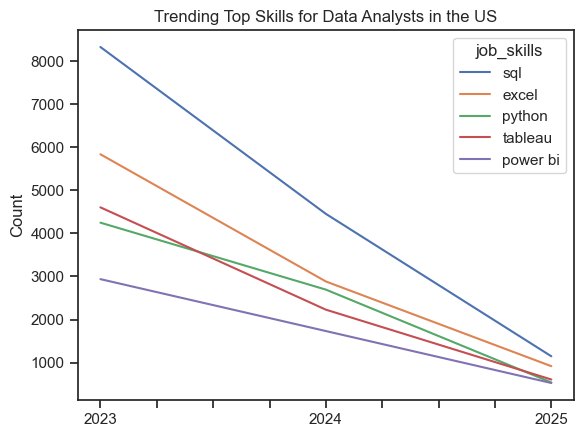

In [20]:
df_DA_US_pivot.iloc[:, :5].plot(kind='line')

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

## Calculate Percentage of Total Jobs

Calculates the total number of entries for each year in `df_DA_US` by grouping the data by 'year' and counting the number of occurrences in each group, storing the results in `DA_totals`. This is needed to compute the percentages.

In [22]:
# Get monthly totals
DA_totals = df_DA_US.groupby('job_posted_year').size()

DA_totals

job_posted_year
2023    14107
2024     7461
2025     1976
dtype: int64

In [23]:
# divide first 3 rows of df_DA_US_pivot by DA_totals
df_DA_US_percent = df_DA_US_pivot.div(DA_totals/100, axis=0)

df_DA_US_percent


job_skills,sql,excel,python,tableau,power bi,sas,r,word,powerpoint,oracle,...,redhat,ringcentral,electron,colocation,clojure,sqlserver,svelte,symphony,chainer,nltk
job_posted_year,,,,,,,,,,,,,,,,,,,,,
2023,58.984901,41.348267,30.105621,32.622103,20.819451,19.366272,18.657404,9.194017,9.123130,7.634508,...,0.000000,0.007089,0.007089,0.007089,0.007089,0.007089,0.007089,0.007089,0.007089,0.007089
2024,59.656882,38.640933,36.107760,29.875352,23.227449,20.881919,21.431444,8.443908,7.277845,5.052942,...,0.013403,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025,58.097166,46.457490,27.327935,30.819838,26.720648,25.303644,16.143725,5.010121,5.516194,4.453441,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Plot Yearly Skill Demand 

Creates a line plot for the top five skills of data analysts, shown as percentages of the total job entries per month, using the first 5 columns of the `df_DA_US_percent` DataFrame. Also the legend is moved outside of the plot for readability.

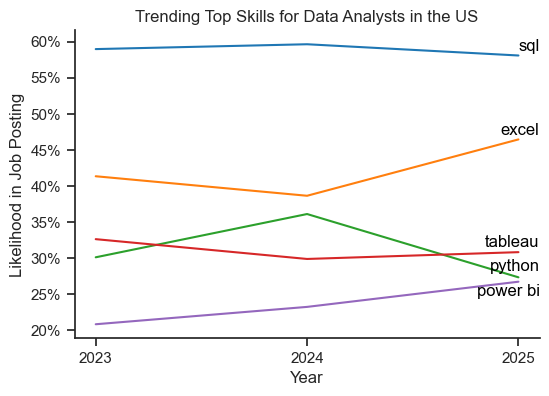

In [ ]:
from matplotlib.ticker import PercentFormatter
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(6, 4))

df_plot = df_DA_US_percent.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10', ax=ax)
sns.set_theme(style='ticks')
sns.despine(ax=ax) # remove top and right spines

years = df_plot.index.astype(int).to_list()
ax.set_xticks(years)
ax.set_xticklabels(years)

ax.set_title('Trending Top Skills for Data Analysts in the US')
ax.set_ylabel('Likelihood in Job Posting')
ax.set_xlabel('Year')
ax.legend_.remove()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
texts = []
for i in range(5):
    texts.append(ax.text(2025.1, df_plot.iloc[-1, i], df_plot.columns[i], color='black'))
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='grey', lw=1))

plt.show()